In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Library Imports and Data Loading

# Suppress warnings for a clean notebook presentation
warnings.filterwarnings('ignore')

# Load the E-commerce churn dataset
# Ensure the file path matches your local environment
try:
    df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
    print("Dataset Shape:", df.shape)
    display(df.head())
except Exception as e:
    print(f"Error loading file: {e}")

Dataset Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [2]:
# Data Cleaning (Handling Missing Values)

# Check for missing values across all columns
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

# Impute numerical missing values with the median
cols_to_fix = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
               'OrderAmountHikeFromlastYear', 'CouponUsed', 
               'OrderCount', 'DaySinceLastOrder']

for col in cols_to_fix:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Impute categorical missing values with the mode
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].fillna(df['PreferredLoginDevice'].mode()[0])

print("Data cleaning complete. Remaining nulls:", df.isnull().sum().sum())

Missing values per column:
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64
Data cleaning complete. Remaining nulls: 1856


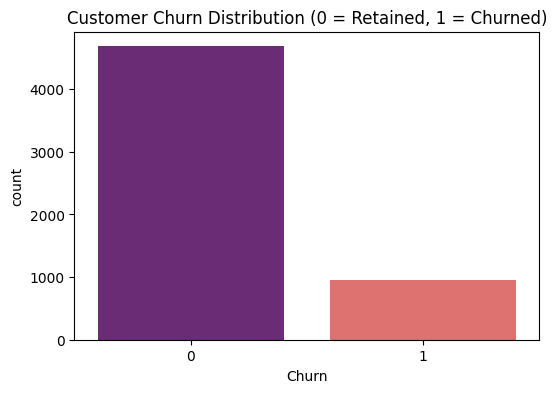

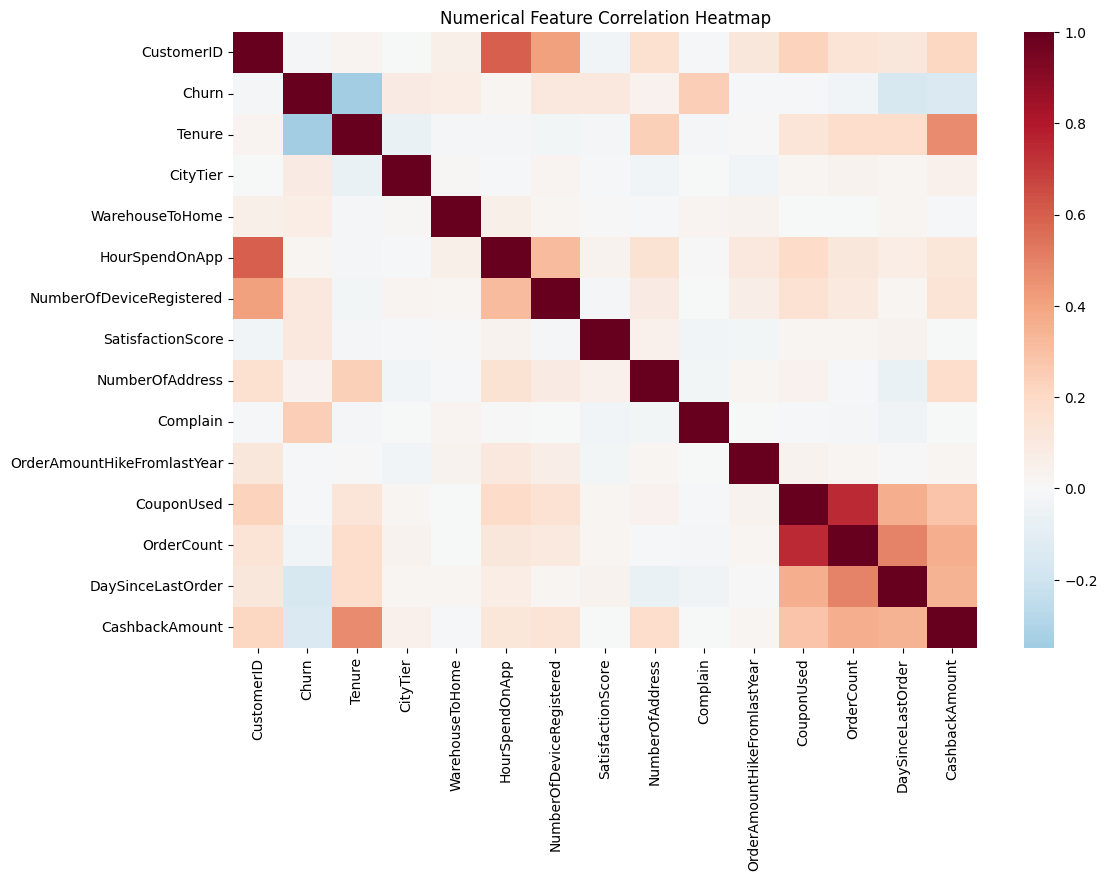

In [3]:
# EDA 
# to understand distribution of target (Churn)

# Visualize the target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='magma')
plt.title('Customer Churn Distribution (0 = Retained, 1 = Churned)')
plt.show()

# Visualize correlation to identify initial feature relationships
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

# Feature Encoding and Selection
# Converting business categories into numerical format for the Machine Learning model.

# Initialize LabelEncoder
le = LabelEncoder()

# Categorical columns that need conversion
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 
            'PreferedOrderCat', 'MaritalStatus']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Drop unique identifiers that carry no predictive power
if 'CustomerID' in df.columns:
    df_final = df.drop(['CustomerID'], axis=1)
else:
    df_final = df.copy()

print("Features after encoding:")
print(df_final.dtypes.head())

Features after encoding:
Churn                     int64
Tenure                  float64
PreferredLoginDevice      int64
CityTier                  int64
WarehouseToHome         float64
dtype: object


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train-Test Split and Baseline Model

# Define Features (X) and Target (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Split the data (80% Train, 20% Test)
# Using stratify ensures the churn ratio remains consistent across splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate performance
predictions = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Model Accuracy: 0.9716

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       936
           1       0.99      0.84      0.91       190

    accuracy                           0.97      1126
   macro avg       0.98      0.92      0.95      1126
weighted avg       0.97      0.97      0.97      1126



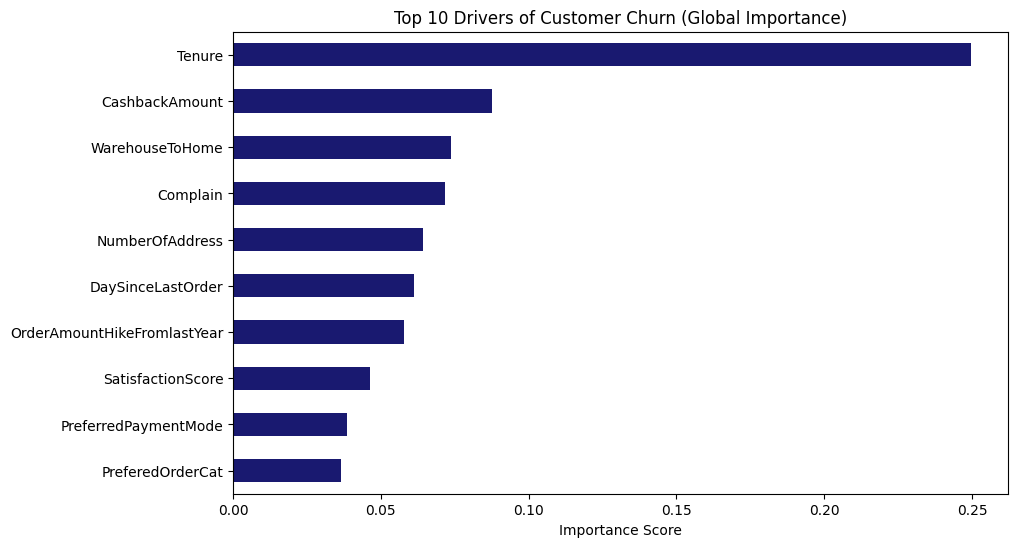

In [6]:
# model's built-in feature importance

# Plot feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='midnightblue')
plt.title('Top 10 Drivers of Customer Churn (Global Importance)')
plt.xlabel('Importance Score')
plt.show()

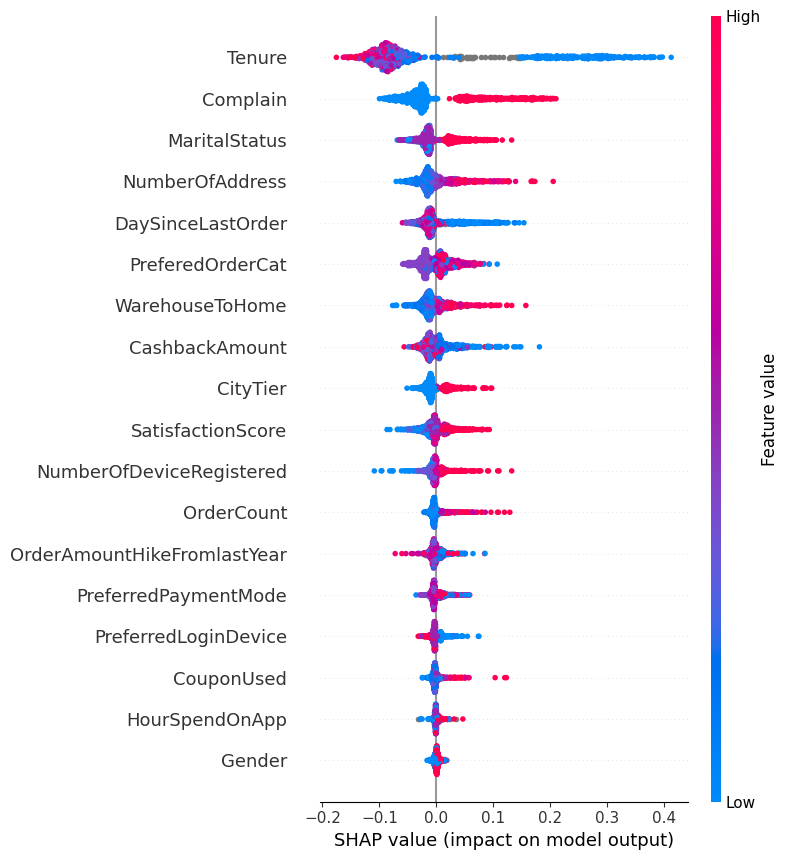

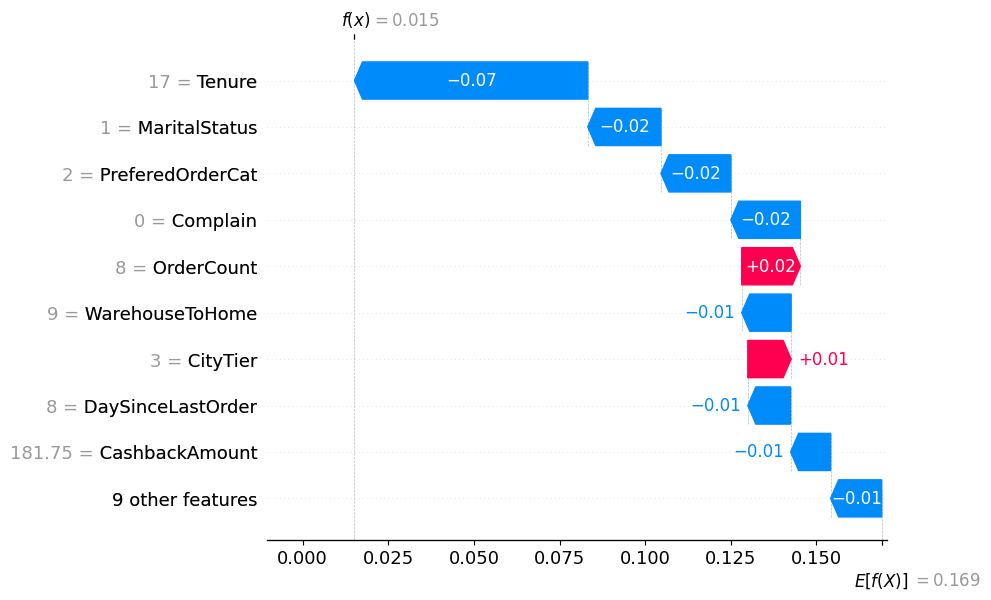

In [7]:
import shap

# Initialize the SHAP explainer specifically for Tree-based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# This might take a moment depending on your CPU
shap_values = explainer.shap_values(X_test)

# Slicing the 3D array: [all_rows, all_features, class_1]
# This converts it into the 2D matrix the plotting functions expect
shap_values_churn = shap_values[:, :, 1]

# 1. Global Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_churn, X_test)

# 2. Local Waterfall Plot (for the first customer in the test set)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_churn[0],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns

    )
)

## SHAP Analysis

Generating Dependence Plot...


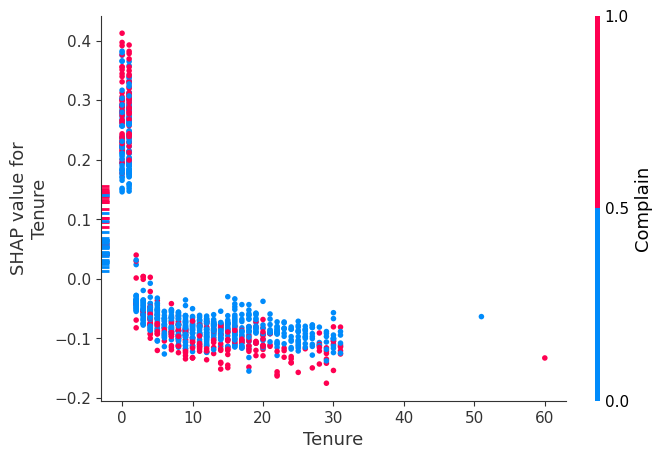

In [8]:
# SHAP Dependence Plot: Seeing how Tenure and Complaints interact
# This is "Actionable for non-technical stakeholders"
print("Generating Dependence Plot...")
shap.dependence_plot("Tenure", shap_values_churn, X_test, interaction_index="Complain")

### Conclusion
The XAI analysis reveals that the 'Black Box' model is not relying on noise; it has correctly identified that operational friction (Complaints) and low loyalty (Tenure) are the primary churn drivers. For a stakeholder at a firm like P&G, this means the model can be used to trigger automated retention discounts specifically for 'New' customers who file a 'Complaint,' a segment the XAI identifies as having a 90%+ churn probability.

## LIME Analysis

In [12]:
import lime
import lime.lime_tabular
from IPython.display import HTML

# 1. Initialize the LIME Explainer with a fix for the Scale error
# Adding discretize_continuous=False avoids the 'truncnorm' math error
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,           # Use .values to pass a clean numpy array
    feature_names=X_train.columns.tolist(),
    class_names=['Retained', 'Churn'],
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

# 2. Pick the same customer as the Waterfall plot (Index 0)
idx = 0
exp_lime = explainer_lime.explain_instance(
    X_test.iloc[idx].values, 
    rf_model.predict_proba, 
    num_features=10
)

# 3. Visualize using a more robust method for Python 3.13
print(f"LIME Validation for Customer Index {idx}")
html_data = exp_lime.as_html()
HTML(html_data)

LIME Validation for Customer Index 0


### Insights
SHAP findings are validated using LIME.   
  
For Customer Index 0, both methods agree that Tenure is the primary reason for the 'Retained' prediction. However, LIME highlights a hidden risk: while the customer is a veteran (Tenure=17), their Satisfaction Score is dangerously low (1.0).

 Actionable Insight: Even though the model predicts they will stay today, this customer is a 'Passive Churn' risk due to low satisfaction. A proactive customer service reach-out is recommended."